In [15]:
#1. Imports

In [3]:
# pandas wird für Datenanalyse und Tabellen verwendet
import pandas as pd

# numpy wird für mathematische Berechnungen verwendet
import numpy as np

# json wird benötigt um die API Daten (JSON Dateien) einzulesen
import json

# matplotlib wird für die Erstellung von Grafiken verwendet
import matplotlib.pyplot as plt


In [ ]:
#2. Konfiguration

In [4]:
# pathlib erleichtert das Arbeiten mit Dateipfaden
from pathlib import Path

# Basisordner des Projekts
BASE_DIR = Path(".")

# Datei mit Butter Verbraucherpreisen (Consumer Price Index)
BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"

# Datei mit Dairy Producer Price Index (Produktionskosten)
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"

# Optionale Datei mit breiter Dairy CPI
DAIRY_CPI_FILE = BASE_DIR / "eurostat_cpi_dairy.json"

# Analysezeitraum definieren
ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END = pd.Timestamp("2024-12-31")

In [ ]:
#3. Eurostat JSON Funktion 

In [5]:
def eurostat_json_to_df(file_path, value_name):

    # Öffnet die JSON Datei im Lesemodus
    with open(file_path, "r", encoding="utf-8") as file:

        # JSON Inhalt wird als Python Dictionary geladen
        data = json.load(file)

    # Zeitindex enthält die Position jedes Monats im Wertearray
    time_index = data["dimension"]["time"]["category"]["index"]

    # Zeitlabels enthalten die tatsächlichen Monatsbezeichnungen
    time_labels = data["dimension"]["time"]["category"]["label"]

    # values enthält die tatsächlichen Preiswerte
    values = data["value"]

    # Liste für alle späteren Tabellenzeilen
    rows = []

    # Schleife über alle Monate im Datensatz
    for label_key, position in time_index.items():

        # Position wird in String umgewandelt
        position_str = str(position)

        # Nur Monate mit vorhandenen Werten werden übernommen
        if position_str in values:

            # Neue Zeile wird erstellt
            rows.append(
                {
                    "datum_raw": time_labels[label_key],
                    value_name: values[position_str],
                }
            )

    # Liste wird in einen pandas DataFrame umgewandelt
    df = pd.DataFrame(rows)

    # Datum wird in ein echtes Datumsformat umgewandelt
    df["datum"] = pd.to_datetime(
        df["datum_raw"].str.replace("M", "-"),
        errors="coerce"
    )

    # Hilfsspalte wird gelöscht
    df.drop(columns=["datum_raw"], inplace=True)

    # Werte werden sicherheitshalber in numerische Werte konvertiert
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    # Bereinigter DataFrame wird zurückgegeben
    return df

In [ ]:
#4. Datenbereinigung 

In [6]:
def clean_time_series(df, value_column, start_date, end_date):

    # Kopie des DataFrames erstellen damit Originaldaten nicht verändert werden
    cleaned_df = df.copy()

    # Zeilen mit fehlendem Datum oder fehlendem Wert werden entfernt
    cleaned_df = cleaned_df.dropna(subset=["datum", value_column])

    # Falls ein Monat mehrfach vorkommt wird nur der letzte Eintrag behalten
    cleaned_df = cleaned_df.drop_duplicates(subset=["datum"], keep="last")

    # Daten werden chronologisch sortiert
    cleaned_df = cleaned_df.sort_values("datum").reset_index(drop=True)

    # Daten werden auf den Analysezeitraum begrenzt
    cleaned_df = cleaned_df[
        (cleaned_df["datum"] >= start_date) &
        (cleaned_df["datum"] <= end_date)
    ]

    # Bereinigte Zeitreihe wird zurückgegeben
    return cleaned_df

In [ ]:
#5. JSON-Daten hochladen 

In [7]:
# Butter CPI Daten werden aus der JSON Datei geladen
butter_raw = eurostat_json_to_df(BUTTER_FILE, "butter_cpi")

# Dairy PPI Daten werden aus der JSON Datei geladen
ppi_raw = eurostat_json_to_df(PPI_FILE, "dairy_ppi")

# Daten werden bereinigt
butter = clean_time_series(butter_raw, "butter_cpi", ANALYSIS_START, ANALYSIS_END)

# Daten werden bereinigt
ppi = clean_time_series(ppi_raw, "dairy_ppi", ANALYSIS_START, ANALYSIS_END)

In [ ]:
#6. Daten zusammenführen 

In [8]:
# Butter CPI und Dairy PPI werden über das Datum zusammengeführt
df = pd.merge(butter, ppi, on="datum")

# Daten werden erneut chronologisch sortiert
df = df.sort_values("datum")

In [ ]:
#7. Margin Analyse 

In [9]:
# jährliche Inflationsrate für Butter (YoY Veränderung)
df["butter_yoy"] = df["butter_cpi"].pct_change(12) * 100

# jährliche Inflationsrate für Produktionskosten
df["ppi_yoy"] = df["dairy_ppi"].pct_change(12) * 100

# Differenz zwischen Retail Inflation und Produktionskosten Inflation
df["inflation_gap"] = df["butter_yoy"] - df["ppi_yoy"]

# absolute Differenz zwischen Retailpreis und Produktionskosten
df["cpi_ppi_gap"] = df["butter_cpi"] - df["dairy_ppi"]

In [ ]:
#Line Chart 

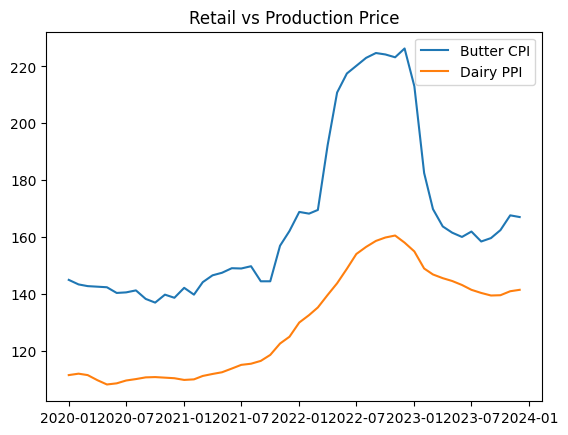

In [10]:
# neue Grafik erstellen
plt.figure()

# Butter CPI über Zeit plotten
plt.plot(df["datum"], df["butter_cpi"], label="Butter CPI")

# Dairy PPI über Zeit plotten
plt.plot(df["datum"], df["dairy_ppi"], label="Dairy PPI")

# Legende anzeigen
plt.legend()

# Titel der Grafik
plt.title("Retail vs Production Price")

# Grafik anzeigen
plt.show()

In [ ]:
#Bar chart 

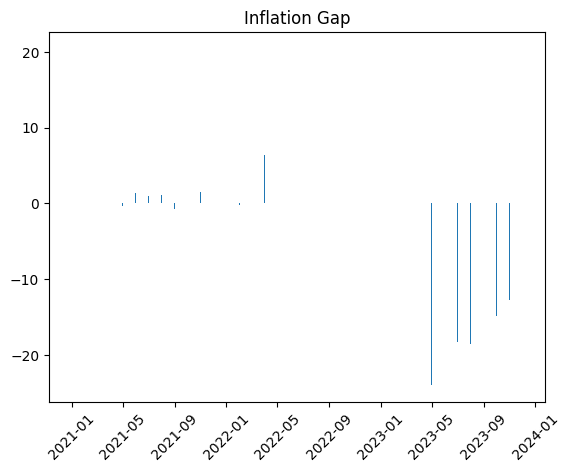

In [11]:
# neue Grafik erstellen
plt.figure()

# Inflation Gap als Balkendiagramm darstellen
plt.bar(df["datum"], df["inflation_gap"])

# x-Achse drehen damit Monate lesbar sind
plt.xticks(rotation=45)

# Titel setzen
plt.title("Inflation Gap")

# Grafik anzeigen
plt.show()

In [ ]:
#Scatter Plot 

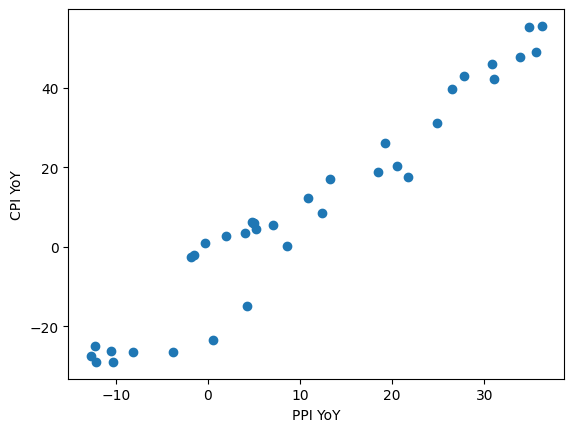

In [12]:
# neue Grafik erstellen
plt.figure()

# Zusammenhang zwischen Produktionskosten Inflation und Retail Inflation
plt.scatter(df["ppi_yoy"], df["butter_yoy"])

# Achsen beschriften
plt.xlabel("PPI YoY")
plt.ylabel("CPI YoY")

# Grafik anzeigen
plt.show()

In [ ]:
#Boxplot 

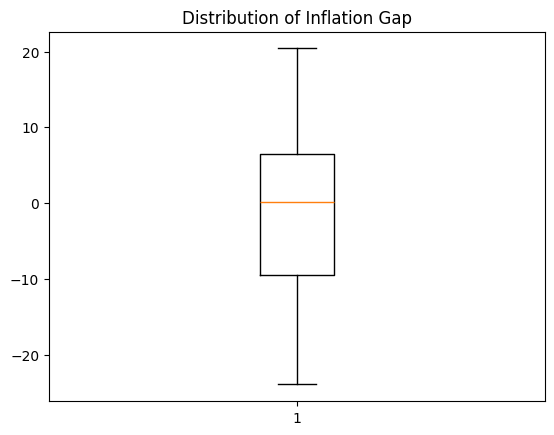

In [13]:
# neue Grafik erstellen
plt.figure()

# Verteilung der Inflation Gap Werte darstellen
plt.boxplot(df["inflation_gap"].dropna())

# Titel setzen
plt.title("Distribution of Inflation Gap")

# Grafik anzeigen
plt.show()